In [1]:
import torch
import torch.nn as nn
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
wine = load_wine()
X = StandardScaler().fit_transform(wine.data)
X_t = torch.FloatTensor(X).to(device)

In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(13, 2)
        self.decoder = nn.Linear(2, 13)
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

In [4]:
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
for epoch in range(100):
    optimizer.zero_grad()
    recon, _ = model(X_t)
    loss = criterion(recon, X_t)
    loss.backward()
    optimizer.step()

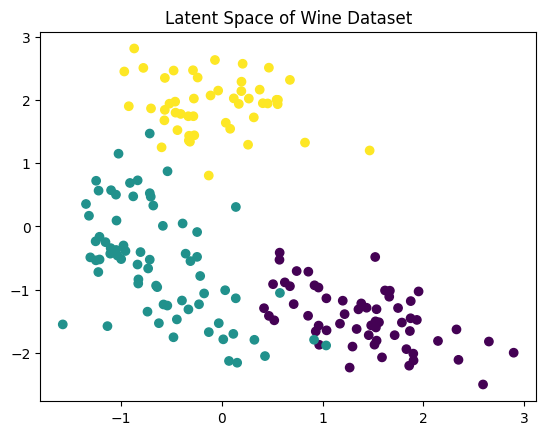

In [5]:
with torch.no_grad():
    _, z = model(X_t)
    z = z.cpu().numpy()
plt.scatter(z[:, 0], z[:, 1], c=wine.target)
plt.title('Latent Space of Wine Dataset')
plt.savefig('wine_latent.png')